In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter("ignore")

In [2]:
data = pd.read_csv("train.csv")
data.head()

,Unnamed: 0,id,age,bp,sg,al,su,rbc,pc,pcc,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
1,18,18,60.0,100.0,1.025,0.0,3.0,NaN,normal,notpresent,...,37,11400,4.3,yes,yes,yes,good,no,no,ckd
2,202,202,78.0,60.0,NaN,NaN,NaN,NaN,NaN,notpresent,...,24,NaN,NaN,no,yes,no,good,no,yes,ckd
3,250,250,40.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,...,48,10400,4.5,no,no,no,good,no,no,notckd
4,274,274,19.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,...,44,NaN,NaN,no,no,no,good,no,no,notckd


In [3]:
data.classification.unique()

<StringArray>
['ckd', 'notckd', 'ckd\t']
Length: 3, dtype: str

In [4]:
data["classification"].value_counts()

classification
ckd       196
notckd    122
ckd\t       2
Name: count, dtype: int64

In [5]:
data.drop(columns=['Unnamed: 0', 'id'], inplace=True)

In [6]:
data.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')

In [7]:
data.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [8]:
data.tail()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
315,46.0,60.0,1.010,1.0,0.0,normal,normal,notpresent,notpresent,163.0,...,28,14600,3.2,yes,yes,no,good,no,no,ckd
316,50.0,90.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,89.0,...,17,6500,NaN,yes,yes,no,good,yes,yes,ckd
317,23.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,111.0,...,41,7200,5.0,no,no,no,good,no,no,notckd
318,38.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,99.0,...,44,7300,6.4,no,no,no,good,no,no,notckd
319,17.0,60.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,92.0,...,52,7000,NaN,no,no,no,good,no,no,ckd


In [9]:
data.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin
count,315.000000,309.000000,283.000000,284.000000,281.000000,285.000000,305.000000,307.000000,246.000000,245.000000,277.000000
mean,50.901587,75.954693,1.017456,0.992958,0.437722,150.308772,55.307213,2.865309,137.445122,4.696327,12.598917
std,17.522501,14.078095,0.005779,1.334492,1.077630,78.066666,50.065851,5.538349,11.157410,3.573724,2.862558
min,2.000000,50.000000,1.005000,0.000000,0.000000,70.000000,10.000000,0.400000,4.500000,2.500000,3.100000
25%,41.000000,70.000000,1.010000,0.000000,0.000000,100.000000,27.000000,0.900000,135.000000,3.800000,10.700000
50%,54.000000,70.000000,1.020000,0.000000,0.000000,123.000000,40.000000,1.200000,138.000000,4.400000,12.700000
75%,64.000000,80.000000,1.020000,2.000000,0.000000,169.000000,60.000000,2.700000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      315 non-null    float64
 1   blood_pressure           309 non-null    float64
 2   specific_gravity         283 non-null    float64
 3   albumin                  284 non-null    float64
 4   sugar                    281 non-null    float64
 5   red_blood_cells          200 non-null    str    
 6   pus_cell                 268 non-null    str    
 7   pus_cell_clumps          316 non-null    str    
 8   bacteria                 316 non-null    str    
 9   blood_glucose_random     285 non-null    float64
 10  blood_urea               305 non-null    float64
 11  serum_creatinine         307 non-null    float64
 12  sodium                   246 non-null    float64
 13  potassium                245 non-null    float64
 14  haemoglobin              277 non-null

In [11]:
data["packed_cell_volume"] = pd.to_numeric(data["packed_cell_volume"], errors = "coerce")
data["white_blood_cell_count"] = pd.to_numeric(data["white_blood_cell_count"], errors = "coerce")
data["red_blood_cell_count"] = pd.to_numeric(data["red_blood_cell_count"], errors = "coerce")

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      315 non-null    float64
 1   blood_pressure           309 non-null    float64
 2   specific_gravity         283 non-null    float64
 3   albumin                  284 non-null    float64
 4   sugar                    281 non-null    float64
 5   red_blood_cells          200 non-null    str    
 6   pus_cell                 268 non-null    str    
 7   pus_cell_clumps          316 non-null    str    
 8   bacteria                 316 non-null    str    
 9   blood_glucose_random     285 non-null    float64
 10  blood_urea               305 non-null    float64
 11  serum_creatinine         307 non-null    float64
 12  sodium                   246 non-null    float64
 13  potassium                245 non-null    float64
 14  haemoglobin              277 non-null

In [15]:
categorical_cols = [col for col in data.columns if data[col].dtype == "str"]
numerical_cols = [col for col in data.columns if data[col].dtype != "str"]

In [16]:
categorical_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [17]:
numerical_cols

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [18]:
for col in categorical_cols:
    print(f"{col} has {data[col].unique()}")

red_blood_cells has <StringArray>
['normal', nan, 'abnormal']
Length: 3, dtype: str
pus_cell has <StringArray>
['abnormal', 'normal', nan]
Length: 3, dtype: str
pus_cell_clumps has <StringArray>
['present', 'notpresent', nan]
Length: 3, dtype: str
bacteria has <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
hypertension has <StringArray>
['yes', 'no', nan]
Length: 3, dtype: str
diabetes_mellitus has <StringArray>
['no', 'yes', nan, '\tyes', '\tno']
Length: 5, dtype: str
coronary_artery_disease has <StringArray>
['no', 'yes', nan, '\tno']
Length: 4, dtype: str
appetite has <StringArray>
['poor', 'good']
Length: 2, dtype: str
peda_edema has <StringArray>
['yes', 'no']
Length: 2, dtype: str
aanemia has <StringArray>
['yes', 'no']
Length: 2, dtype: str
class has <StringArray>
['ckd', 'notckd', 'ckd\t']
Length: 3, dtype: str


In [19]:
# for diabetes_mellitus column
data['diabetes_mellitus'] = data['diabetes_mellitus'].replace({'\tno':'no', '\tyes': 'yes', ' yes':'yes'})

# for coronary_artery_disease column
data['coronary_artery_disease'] = data['coronary_artery_disease'].replace('\tno', 'no')

# for class column
data['class'] = data['class'].replace({'ckd\t':'ckd', 'notckd': 'not ckd'})

In [20]:
cols = ['diabetes_mellitus', 'coronary_artery_disease', 'class']
for col in cols:
    print(f"{col} has {data[col].unique()}")

diabetes_mellitus has <StringArray>
['no', 'yes', nan]
Length: 3, dtype: str
coronary_artery_disease has <StringArray>
['no', 'yes', nan]
Length: 3, dtype: str
class has <StringArray>
['ckd', 'not ckd']
Length: 2, dtype: str


In [21]:
data["class"] = data["class"].map({"ckd":0, "not ckd":1})
data["class"] = pd.to_numeric(data["class"], errors = "coerce")

In [22]:
cols = ['diabetes_mellitus', 'coronary_artery_disease', 'class']
for col in cols:
    print(f"{col} has {data[col].unique()}")

diabetes_mellitus has <StringArray>
['no', 'yes', nan]
Length: 3, dtype: str
coronary_artery_disease has <StringArray>
['no', 'yes', nan]
Length: 3, dtype: str
class has [0 1]


In [23]:
data["class"].value_counts()*100/len(data)

class
0    61.875
1    38.125
Name: count, dtype: float64

In [24]:
data.isnull().sum()

age                          5
blood_pressure              11
specific_gravity            37
albumin                     36
sugar                       39
red_blood_cells            120
pus_cell                    52
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        35
blood_urea                  15
serum_creatinine            13
sodium                      74
potassium                   75
haemoglobin                 43
packed_cell_volume          58
white_blood_cell_count      90
red_blood_cell_count       109
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     0
peda_edema                   0
aanemia                      0
class                        0
dtype: int64

In [25]:
data[numerical_cols].isnull().sum()

age                         5
blood_pressure             11
specific_gravity           37
albumin                    36
sugar                      39
blood_glucose_random       35
blood_urea                 15
serum_creatinine           13
sodium                     74
potassium                  75
haemoglobin                43
packed_cell_volume         58
white_blood_cell_count     90
red_blood_cell_count      109
dtype: int64

In [26]:
data[categorical_cols].isnull().sum()

red_blood_cells            120
pus_cell                    52
pus_cell_clumps              4
bacteria                     4
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     0
peda_edema                   0
aanemia                      0
class                        0
dtype: int64

In [27]:
def random_sampling(feature):
    random_sample = data[feature].dropna().sample(data[feature].isnull().sum())
    random_sample.index = data[data[feature].isnull()].index
    data.loc[data[feature].isnull(), feature] = random_sample

def impute_mode(feature):
    mode = data[feature].mode()[0]
    data[feature] = data[feature].fillna(mode)

In [28]:
for col in numerical_cols:
    random_sampling(col)

In [29]:
data[numerical_cols].isnull().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [30]:
random_sampling('red_blood_cells')
random_sampling('pus_cell')

for col in categorical_cols:
    impute_mode(col)

In [31]:
data[categorical_cols].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

In [32]:
for col in categorical_cols:
    print(f"{col} has {data[col].unique()}")

red_blood_cells has <StringArray>
['normal', 'abnormal']
Length: 2, dtype: str
pus_cell has <StringArray>
['abnormal', 'normal']
Length: 2, dtype: str
pus_cell_clumps has <StringArray>
['present', 'notpresent']
Length: 2, dtype: str
bacteria has <StringArray>
['notpresent', 'present']
Length: 2, dtype: str
hypertension has <StringArray>
['yes', 'no']
Length: 2, dtype: str
diabetes_mellitus has <StringArray>
['no', 'yes']
Length: 2, dtype: str
coronary_artery_disease has <StringArray>
['no', 'yes']
Length: 2, dtype: str
appetite has <StringArray>
['poor', 'good']
Length: 2, dtype: str
peda_edema has <StringArray>
['yes', 'no']
Length: 2, dtype: str
aanemia has <StringArray>
['yes', 'no']
Length: 2, dtype: str
class has [0 1]


In [33]:
for col in categorical_cols:
    print(f"{col} has {data[col].nunique()}")

red_blood_cells has 2
pus_cell has 2
pus_cell_clumps has 2
bacteria has 2
hypertension has 2
diabetes_mellitus has 2
coronary_artery_disease has 2
appetite has 2
peda_edema has 2
aanemia has 2
class has 2


In [34]:
for col in numerical_cols:
    print(f"{col} has {data[col].nunique()}")

age has 74
blood_pressure has 10
specific_gravity has 5
albumin has 6
sugar has 6
blood_glucose_random has 137
blood_urea has 102
serum_creatinine has 73
sodium has 34
potassium has 38
haemoglobin has 104
packed_cell_volume has 39
white_blood_cell_count has 80
red_blood_cell_count has 44


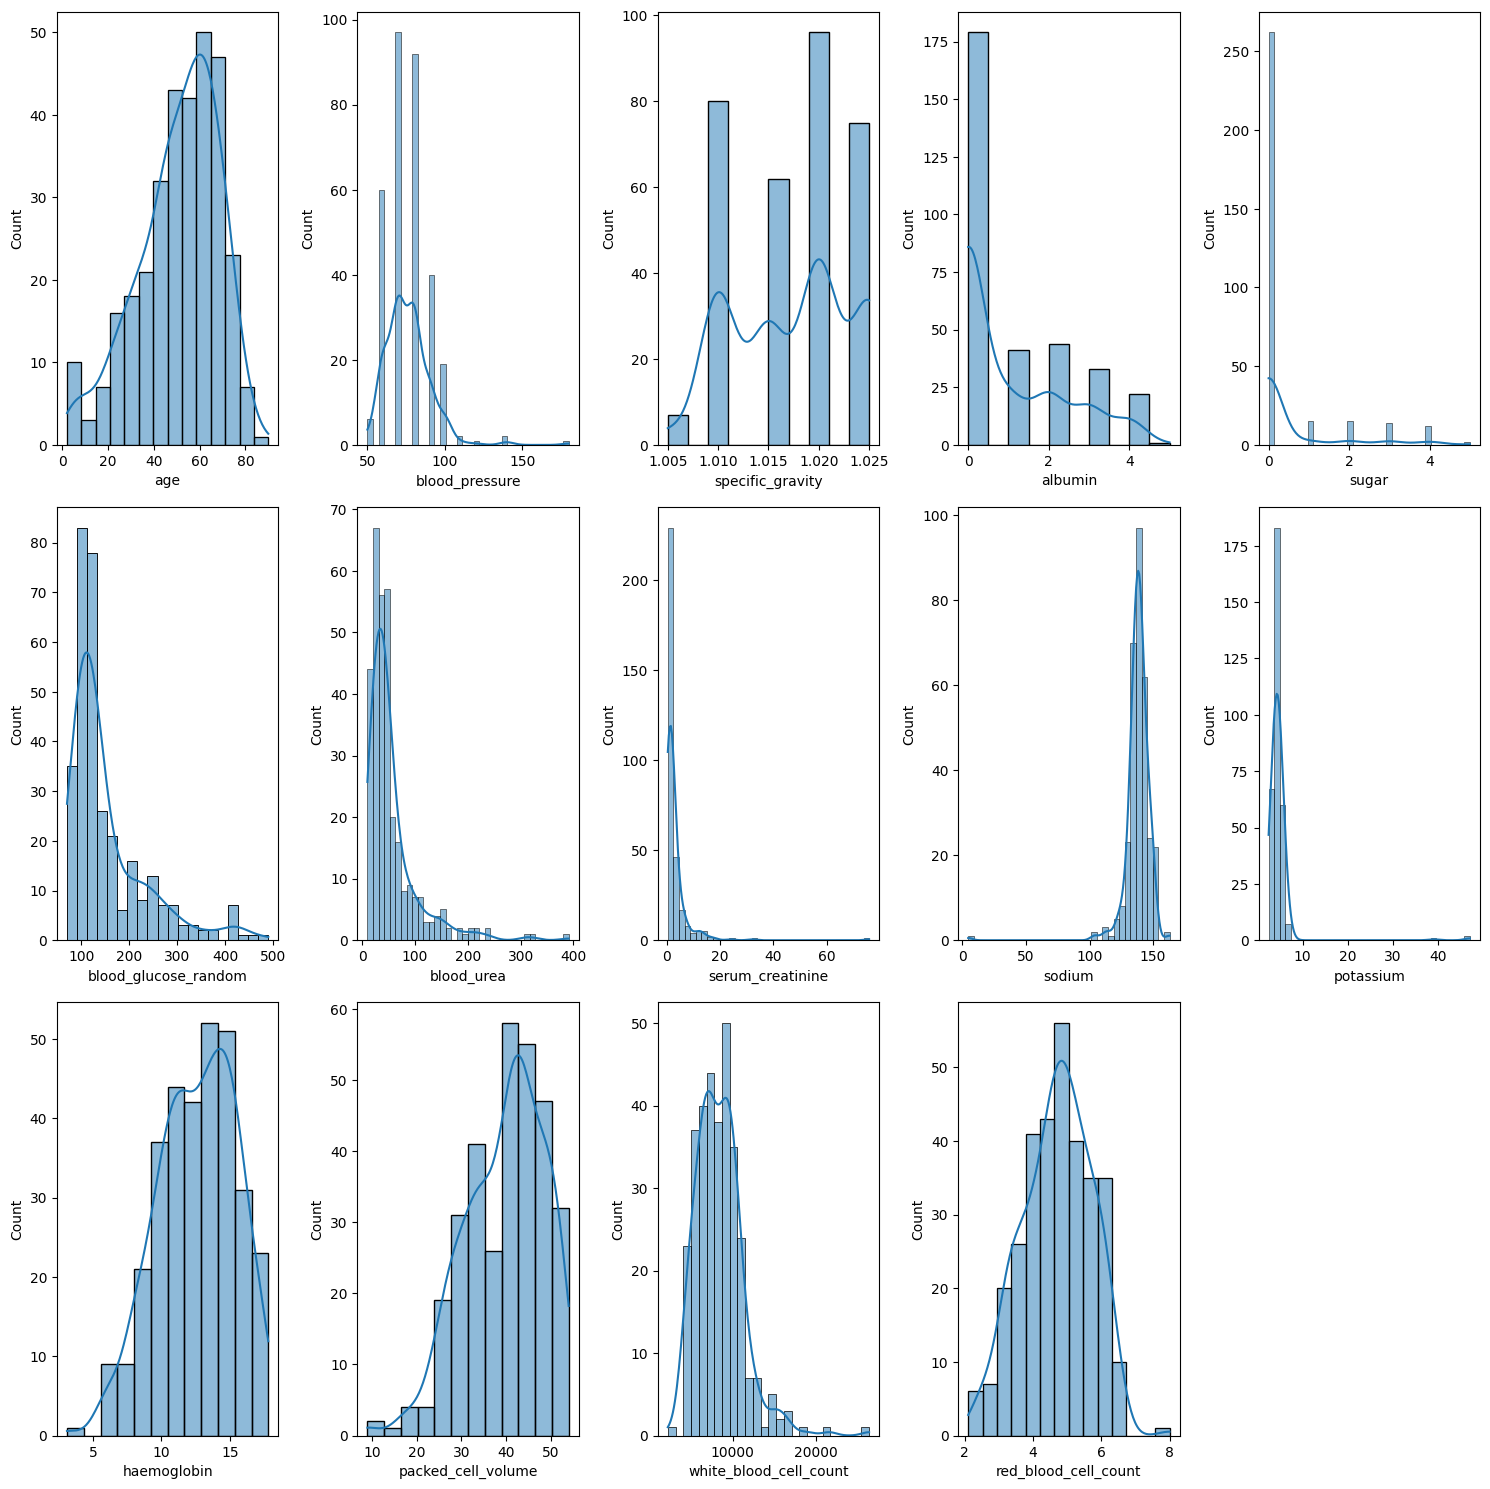

In [35]:
plt.figure(figsize=(15, 15))
plotnumber = 1
for column in numerical_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.histplot(data[column], kde=True, ax=ax)
        plt.xlabel(column)
    plotnumber += 1
plt.tight_layout()
plt.show()

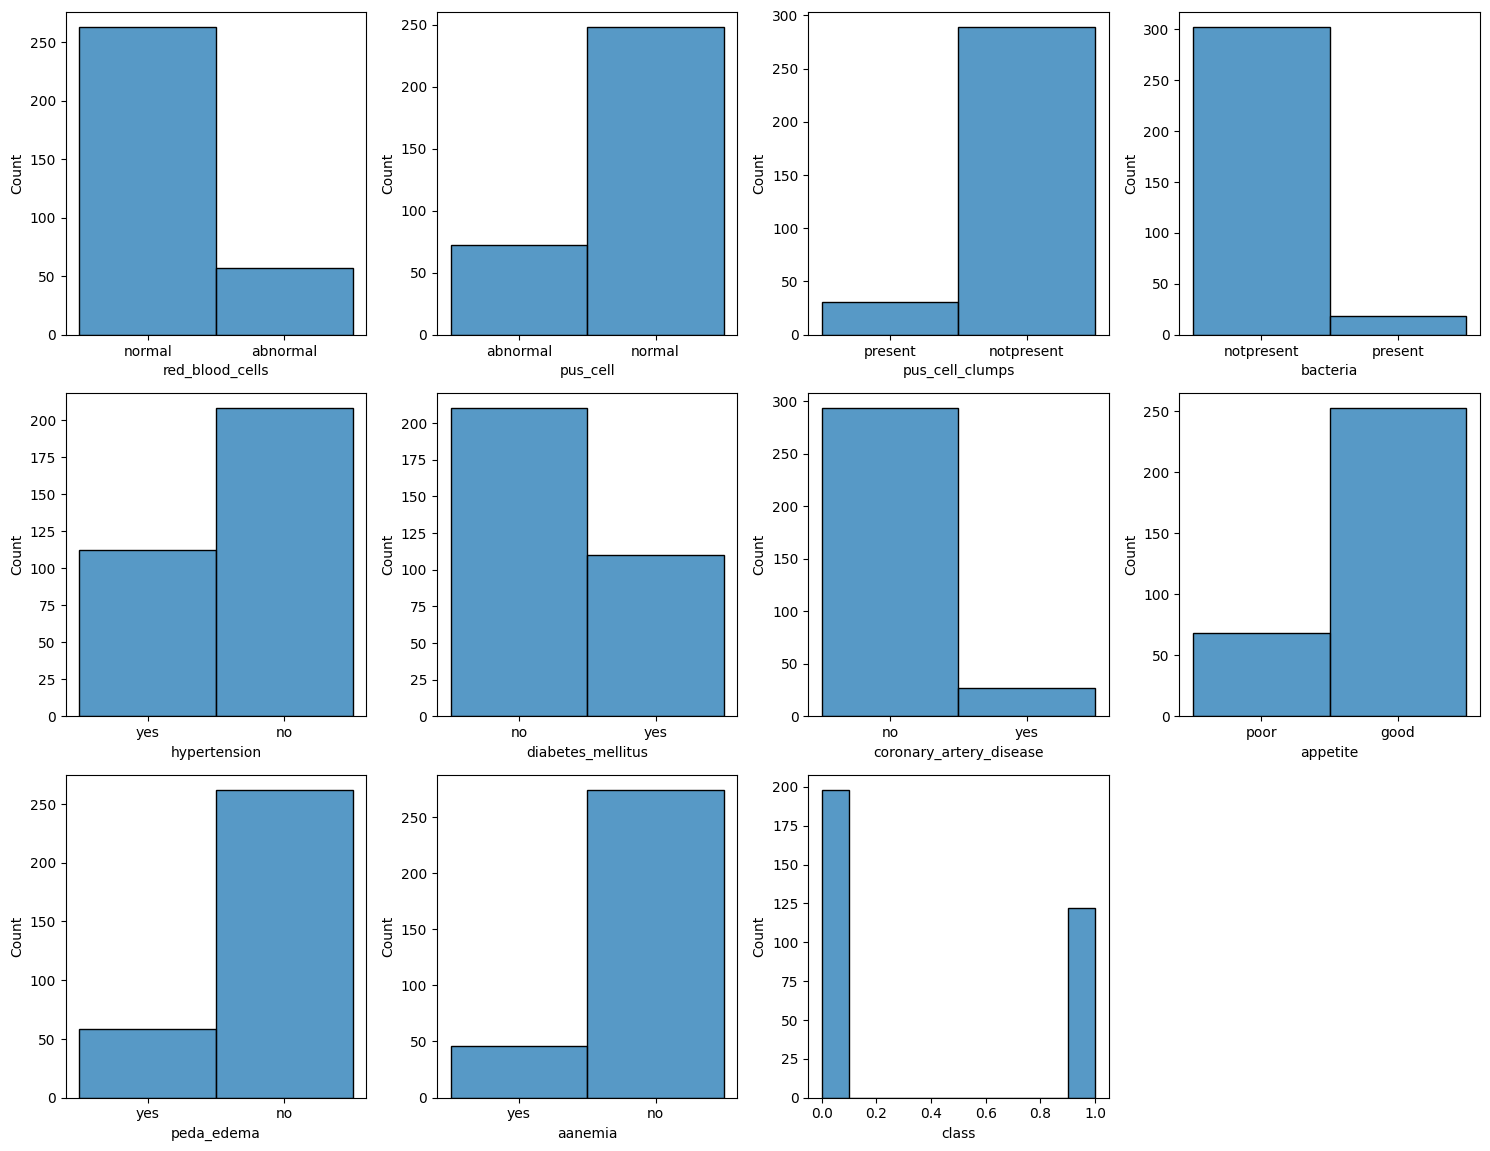

In [36]:
plt.figure(figsize=(15, 15))
plotnumber = 1
for column in categorical_cols:
    if plotnumber <= 14:
        ax = plt.subplot(4, 4, plotnumber)
        sns.histplot(data[column], ax=ax)
        plt.xlabel(column)
    plotnumber += 1
plt.tight_layout()
plt.show()

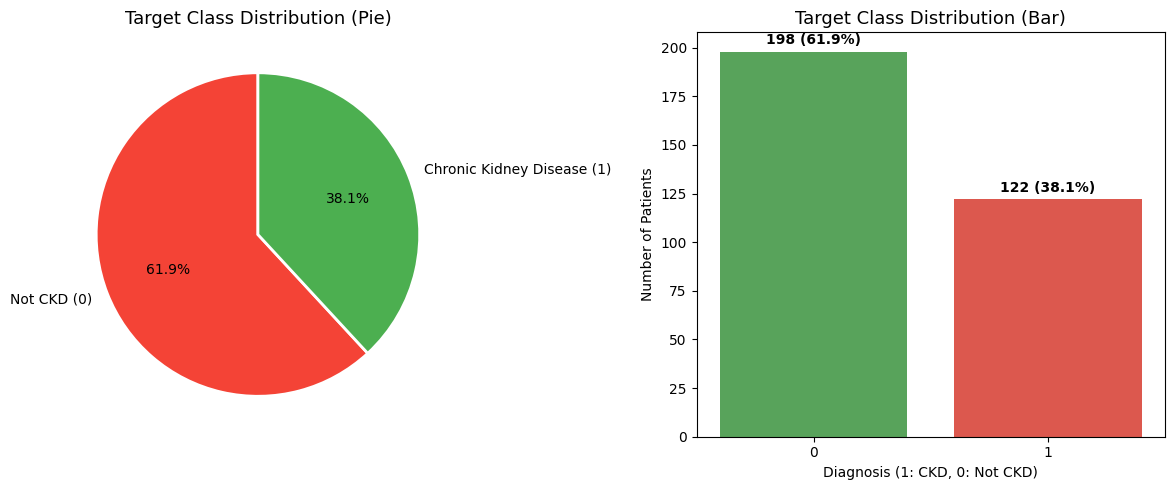

Class Distribution (Counts):
class
0    61.875
1    38.125


In [44]:
counts = data['class'].value_counts()
pcts = counts / len(data) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Chronic Kidney Disease (1)' if str(i) == '1' else 'Not CKD (0)' for i in counts.index]

axes[0].pie(counts, labels=labels,
            autopct='%1.1f%%', colors=['#F44336', '#4CAF50'], 
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Target Class Distribution (Pie)', fontsize=13)

sns.countplot(x='class', data=data, palette={'1': '#F44336', '0': '#4CAF50'}, ax=axes[1])
axes[1].set_title('Target Class Distribution (Bar)', fontsize=13)
axes[1].set_xlabel('Diagnosis (1: CKD, 0: Not CKD)')
axes[1].set_ylabel('Number of Patients')

for p in axes[1].patches:
    height = p.get_height()
    if height > 0: 
        axes[1].annotate(f'{int(height)} ({height/len(data)*100:.1f}%)',
                         (p.get_x() + p.get_width() / 2, height + (max(counts)*0.02)), 
                         ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Class Distribution (Counts):")
print(pcts.to_string())

array([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,

In [45]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [46]:
data.head()

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,1,1,1,0
1,60.0,100.0,1.025,0.0,3.0,1,1,0,0,263.0,...,37.0,11400.0,4.3,1,1,1,0,0,0,0
2,78.0,60.0,1.010,0.0,0.0,0,1,0,0,114.0,...,24.0,11800.0,3.9,0,1,0,0,0,1,0
3,40.0,80.0,1.025,0.0,0.0,1,1,0,0,140.0,...,48.0,10400.0,4.5,0,0,0,0,0,0,1
4,19.0,80.0,1.020,0.0,0.0,1,1,0,0,107.0,...,44.0,12700.0,3.9,0,0,0,0,0,0,1


In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      320 non-null    float64
 1   blood_pressure           320 non-null    float64
 2   specific_gravity         320 non-null    float64
 3   albumin                  320 non-null    float64
 4   sugar                    320 non-null    float64
 5   red_blood_cells          320 non-null    int64  
 6   pus_cell                 320 non-null    int64  
 7   pus_cell_clumps          320 non-null    int64  
 8   bacteria                 320 non-null    int64  
 9   blood_glucose_random     320 non-null    float64
 10  blood_urea               320 non-null    float64
 11  serum_creatinine         320 non-null    float64
 12  sodium                   320 non-null    float64
 13  potassium                320 non-null    float64
 14  haemoglobin              320 non-null

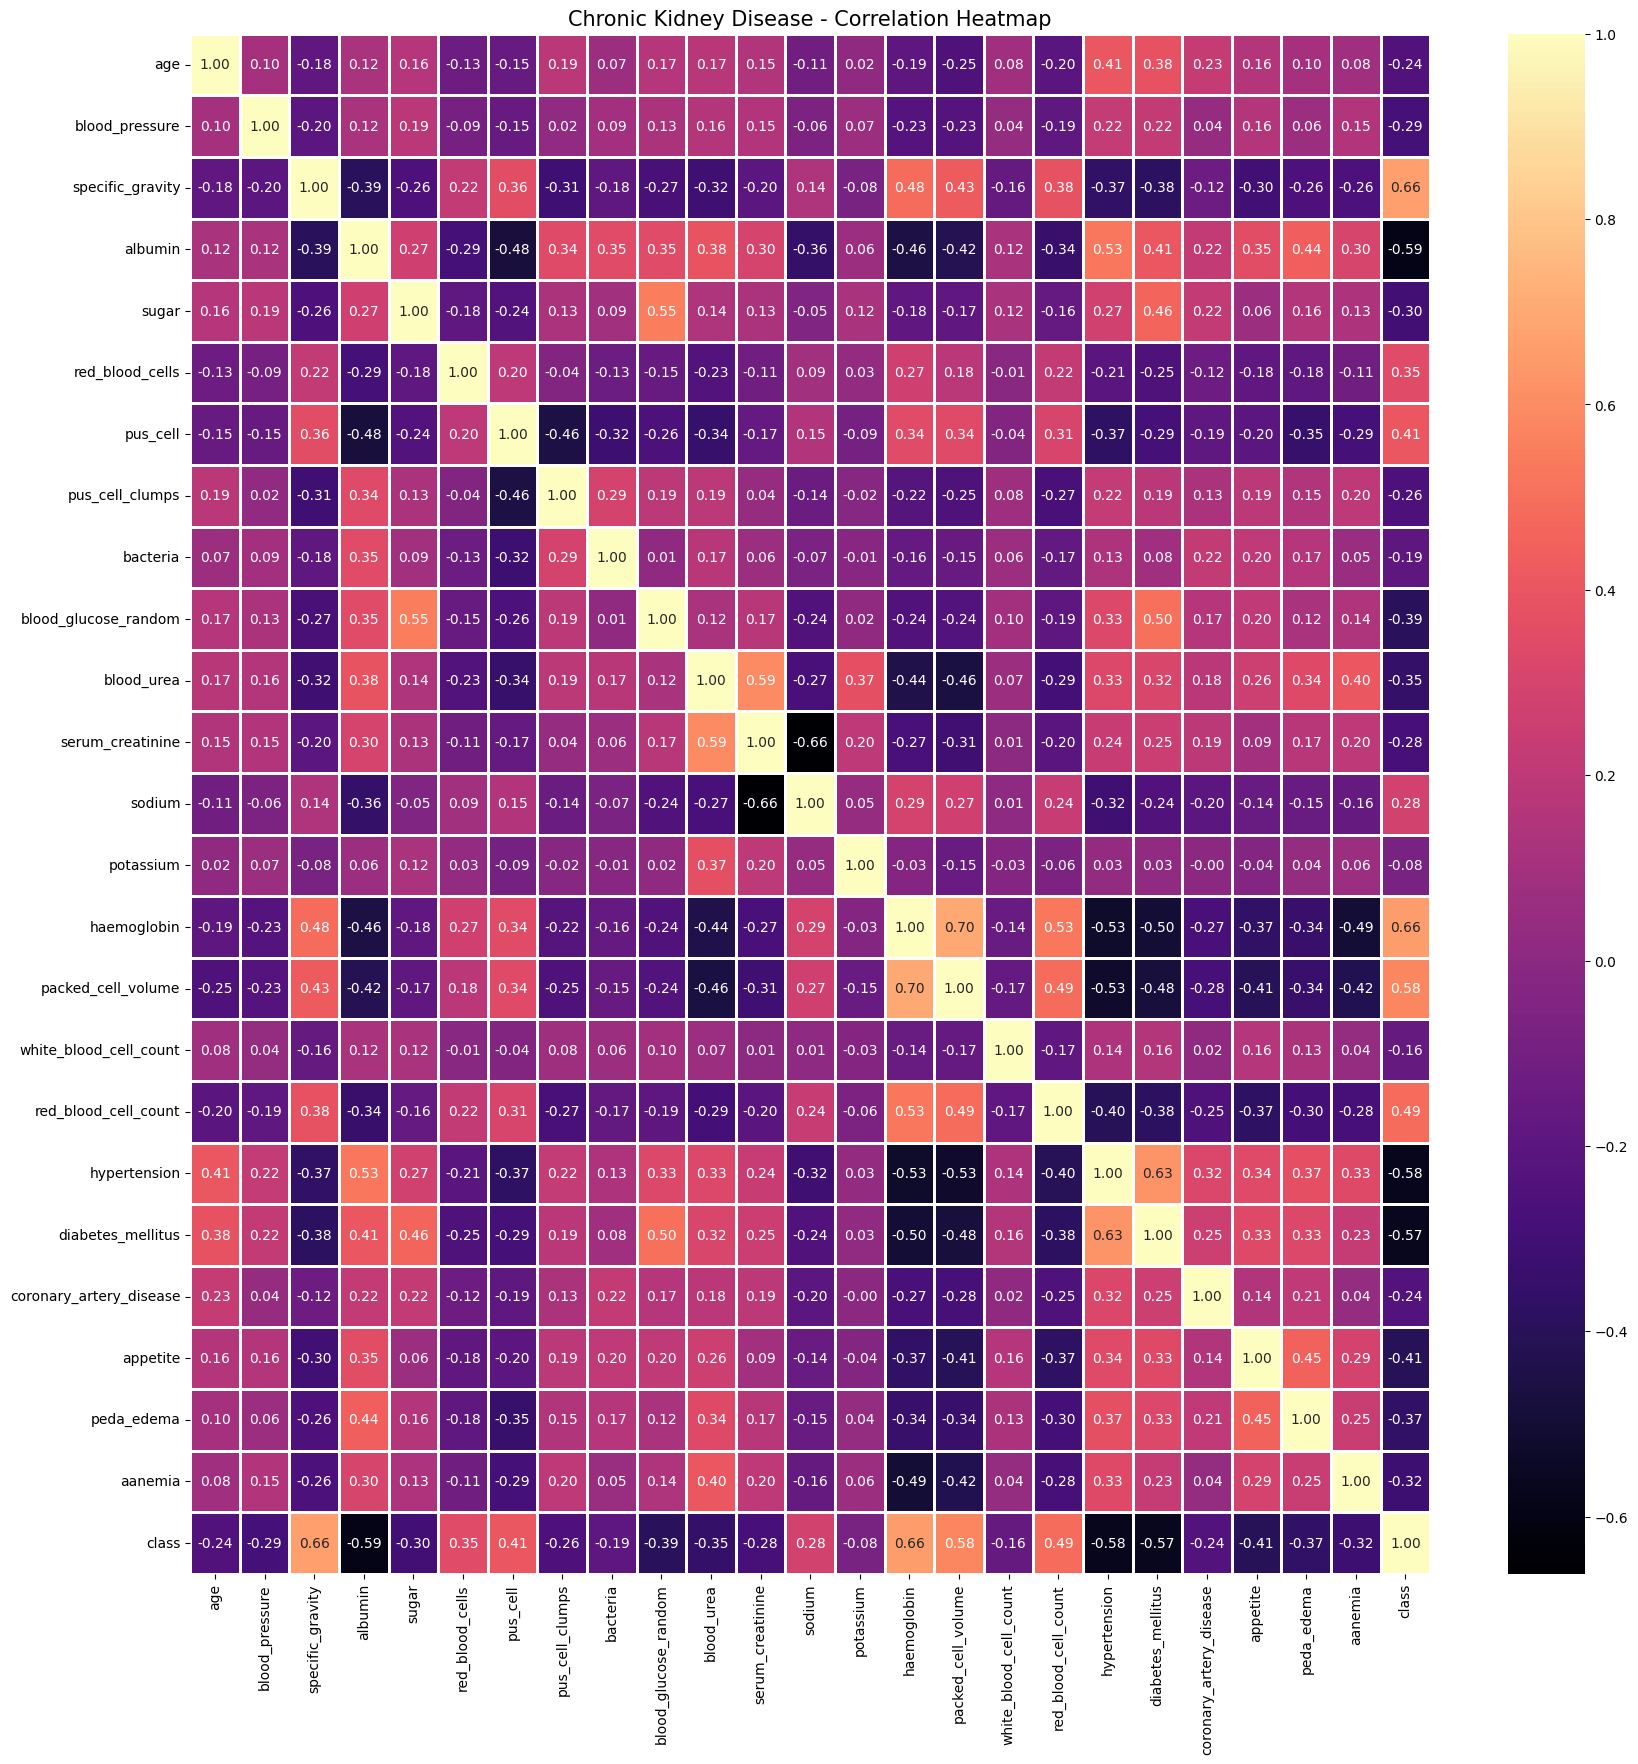

In [49]:
correlation_matrix = data.corr()
plt.figure(figsize=(20, 20)) 
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            linewidths=1, 
            linecolor='white', 
            cmap="magma")
plt.title("Chronic Kidney Disease - Correlation Heatmap", fontsize=15)
plt.show()

In [50]:
X = data.drop("class", axis = 1)
y = data["class"]

In [51]:
y

0      0
1      0
2      0
3      1
4      1
      ..
315    0
316    0
317    1
318    1
319    0
Name: class, Length: 320, dtype: int64

In [52]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Training Accuracy of KNN is 0.7734375
Testing Accuracy of KNN is 0.59375


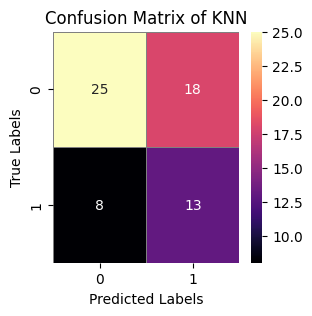

Confusion Matrix of KNN is 
 [[25 18]
 [ 8 13]]

Classification Report of KNN is 
              precision    recall  f1-score   support

           0       0.76      0.58      0.66        43
           1       0.42      0.62      0.50        21

    accuracy                           0.59        64
   macro avg       0.59      0.60      0.58        64
weighted avg       0.65      0.59      0.61        64



In [53]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print(f"Training Accuracy of KNN is {accuracy_score(y_train, knn.predict(X_train))}")
print(f"Testing Accuracy of KNN is {accuracy_score(y_test, knn.predict(X_test))}")
cm = confusion_matrix(y_test, knn.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of KNN')
plt.show()
print(f"Confusion Matrix of KNN is \n {cm}\n")
print(f"Classification Report of KNN is \n{classification_report(y_test, knn.predict(X_test))}")

Training Accuracy of decision tree is 1.0
Testing Accuracy of decision tree is 0.921875


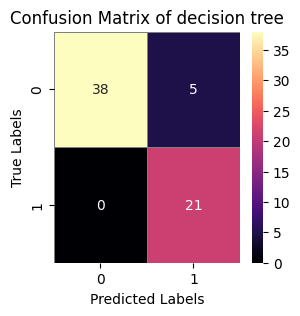

Confusion Matrix of decision tree is 
 [[38  5]
 [ 0 21]]

Classification Report of decision tree is 
              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.81      1.00      0.89        21

    accuracy                           0.92        64
   macro avg       0.90      0.94      0.92        64
weighted avg       0.94      0.92      0.92        64



In [55]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
print(f"Training Accuracy of decision tree is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Testing Accuracy of decision tree is {accuracy_score(y_test, dtc.predict(X_test))}")
cm = confusion_matrix(y_test, dtc.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of decision tree')
plt.show()
print(f"Confusion Matrix of decision tree is \n {cm}\n")
print(f"Classification Report of decision tree is \n{classification_report(y_test, dtc.predict(X_test))}")

In [56]:
# Grid Search CV
from sklearn.model_selection import GridSearchCV
GRID_PARAMETER = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 9],
    "splitter": ["best", "random"],
    "min_samples_leaf": [1, 2, 3, 4, 5],
    "min_samples_split": [2, 3, 4, 5],
    "max_features": ["sqrt", "log2"]
}
grid_search_dtc = GridSearchCV(dtc, GRID_PARAMETER, cv=5, n_jobs=-1, verbose=1)
grid_search_dtc.fit(X_train, y_train)
print(f"Best Parameters: {grid_search_dtc.best_params_}")
print(f"Best Score: {grid_search_dtc.best_score_}")

Fitting 5 folds for each of 640 candidates, totalling 3200 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 3, 'splitter': 'random'}
Best Score: 0.9766214177978882


Training Accuracy of decision tree is 0.9453125
Testing Accuracy of decision tree is 0.921875


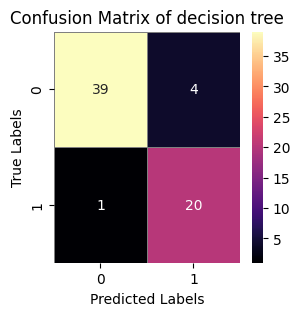

Confusion Matrix of decision tree is 
 [[39  4]
 [ 1 20]]

Classification Report of decision tree is 
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.83      0.95      0.89        21

    accuracy                           0.92        64
   macro avg       0.90      0.93      0.91        64
weighted avg       0.93      0.92      0.92        64



In [57]:
dtc = grid_search_dtc.best_estimator_
print(f"Training Accuracy of decision tree is {accuracy_score(y_train, dtc.predict(X_train))}")
print(f"Testing Accuracy of decision tree is {accuracy_score(y_test, dtc.predict(X_test))}")
cm = confusion_matrix(y_test, dtc.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of decision tree')
plt.show()
print(f"Confusion Matrix of decision tree is \n {cm}\n")
print(f"Classification Report of decision tree is \n{classification_report(y_test, dtc.predict(X_test))}")

Training Accuracy of random forest is 1.0
Testing Accuracy of random forest is 0.984375


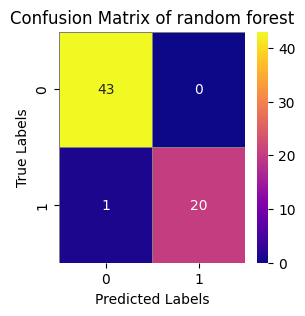

Confusion Matrix of random forest is 
 [[43  0]
 [ 1 20]]

Classification Report of random forest is 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.95      0.98        21

    accuracy                           0.98        64
   macro avg       0.99      0.98      0.98        64
weighted avg       0.98      0.98      0.98        64



In [58]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(criterion = "gini", max_depth = 9, max_features="log2", min_samples_leaf= 2, min_samples_split= 3, n_estimators = 500)
rf.fit(X_train, y_train)
print(f"Training Accuracy of random forest is {accuracy_score(y_train, rf.predict(X_train))}")
print(f"Testing Accuracy of random forest is {accuracy_score(y_test, rf.predict(X_test))}")
cm = confusion_matrix(y_test, rf.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of random forest')
plt.show()
print(f"Confusion Matrix of random forest is \n {cm}\n")
print(f"Classification Report of random forest is \n{classification_report(y_test, rf.predict(X_test))}")

Training Accuracy of xgboost is 0.60546875
Testing Accuracy of xgboost is 0.671875


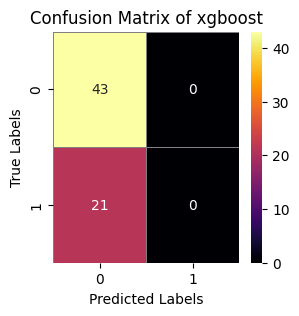

Confusion Matrix of xgboost is 
 [[43  0]
 [21  0]]

Classification Report of xgboost is 
              precision    recall  f1-score   support

           0       0.67      1.00      0.80        43
           1       0.00      0.00      0.00        21

    accuracy                           0.67        64
   macro avg       0.34      0.50      0.40        64
weighted avg       0.45      0.67      0.54        64



In [59]:
#XgBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(objective="binary:logistic", learning_rate = 0.001, max_depth=10, n_estimators=100)
xgb.fit(X_train, y_train)
print(f"Training Accuracy of xgboost is {accuracy_score(y_train, xgb.predict(X_train))}")
print(f"Testing Accuracy of xgboost is {accuracy_score(y_test, xgb.predict(X_test))}")
cm = confusion_matrix(y_test, xgb.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='inferno', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of xgboost')
plt.show()
print(f"Confusion Matrix of xgboost is \n {cm}\n")
print(f"Classification Report of xgboost is \n{classification_report(y_test, xgb.predict(X_test))}")

Training Accuracy of logistic regression is 0.890625
Testing Accuracy of logistic regression is 0.859375


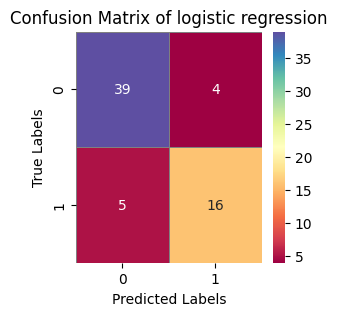

Confusion Matrix of logistic regression is 
 [[39  4]
 [ 5 16]]

Classification Report of logistic regression is 
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        43
           1       0.80      0.76      0.78        21

    accuracy                           0.86        64
   macro avg       0.84      0.83      0.84        64
weighted avg       0.86      0.86      0.86        64



In [60]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
print(f"Training Accuracy of logistic regression is {accuracy_score(y_train, lr.predict(X_train))}")
print(f"Testing Accuracy of logistic regression is {accuracy_score(y_test, lr.predict(X_test))}")
cm = confusion_matrix(y_test, lr.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of logistic regression')
plt.show()
print(f"Confusion Matrix of logistic regression is \n {cm}\n")
print(f"Classification Report of logistic regression is \n{classification_report(y_test, lr.predict(X_test))}")

In [61]:
# SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svm  = SVC(probability=True)
parameter = {
    'gamma':[0.0001, 0.001, 0.01, 0.1],
    'C':[0.01, 0.05, 0.5, 0.1, 1, 5, 10, 15]
}
grid_search = GridSearchCV(svm, parameter)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.05, ...], 'gamma': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fo

In [62]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'C': 5, 'gamma': 0.001}
0.7150829562594269


In [63]:
svm  = SVC(gamma = 0.001, C  = 5, probability=True)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Training Accuracy of svm is 1.0
Testing Accuracy of svm is 0.75


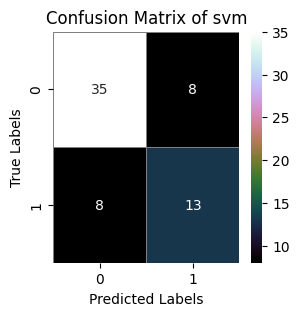

Confusion Matrix of svm is 
 [[35  8]
 [ 8 13]]

Classification Report of svm is 
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        43
           1       0.62      0.62      0.62        21

    accuracy                           0.75        64
   macro avg       0.72      0.72      0.72        64
weighted avg       0.75      0.75      0.75        64



In [64]:
print(f"Training Accuracy of svm is {accuracy_score(y_train, svm.predict(X_train))}")
print(f"Testing Accuracy of svm is {accuracy_score(y_test, svm.predict(X_test))}")
cm = confusion_matrix(y_test, svm.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='cubehelix', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of svm')
plt.show()
print(f"Confusion Matrix of svm is \n {cm}\n")
print(f"Classification Report of svm is \n{classification_report(y_test, svm.predict(X_test))}")

In [65]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier()
PARAMETERS = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate':[0.001, 0.1, 1, 10],
    'n_estimators':[100,150,200,250]
}
grid_search_gbc = GridSearchCV(gbc, PARAMETERS, cv=5, n_jobs=-1, verbose= 1)
grid_search_gbc.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.001, 0.1, ...], 'loss': ['log_loss', 'exponential'], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displ

In [66]:
print(grid_search_gbc.best_params_)
print(grid_search_gbc.best_score_)

{'learning_rate': 0.1, 'loss': 'log_loss', 'n_estimators': 200}
0.9805429864253394


In [67]:
gbc = GradientBoostingClassifier(learning_rate= 0.1, loss = 'exponential', n_estimators = 150)
gbc.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'exponential'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t`

Training Accuracy of gbc is 1.0
Testing Accuracy of gbc is 0.96875


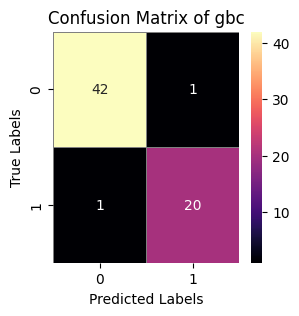

Confusion Matrix of gbc is 
 [[42  1]
 [ 1 20]]

Classification Report of gbc is 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        43
           1       0.95      0.95      0.95        21

    accuracy                           0.97        64
   macro avg       0.96      0.96      0.96        64
weighted avg       0.97      0.97      0.97        64



In [68]:
print(f"Training Accuracy of gbc is {accuracy_score(y_train, gbc.predict(X_train))}")
print(f"Testing Accuracy of gbc is {accuracy_score(y_test, gbc.predict(X_test))}")
cm = confusion_matrix(y_test, gbc.predict(X_test))
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix of gbc')
plt.show()
print(f"Confusion Matrix of gbc is \n {cm}\n")
print(f"Classification Report of gbc is \n{classification_report(y_test, gbc.predict(X_test))}")

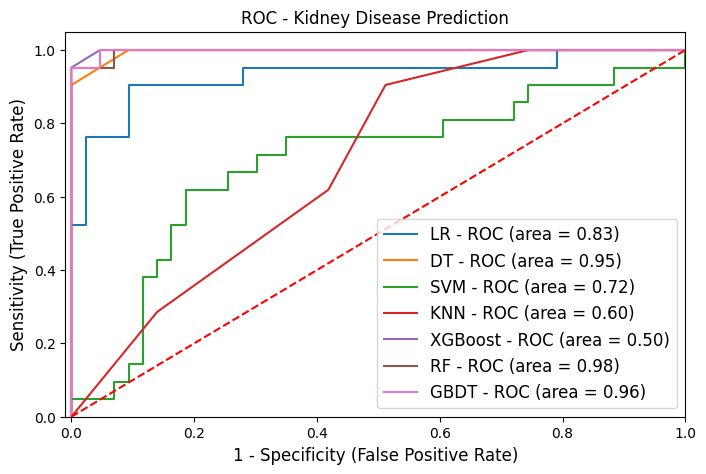

In [69]:
from sklearn import metrics
plt.figure(figsize=(8,5))
models = [
{
    'label': 'LR',
    'model': lr,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svm,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]
for m in models:
    model = m['model'] 
    model.fit(X_train, y_train) 
    y_pred=model.predict(X_test) 
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = metrics.roc_auc_score(y_test,model.predict(X_test))
    plt.plot(fpr1, tpr1, label='%s - ROC (area = %0.2f)' % (m['label'], auc))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Kidney Disease Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("roc_kidney.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

In [70]:
import pickle
model = rf
pickle.dump(model, open("kidney_disease.pkl", 'wb'))